<a href="https://colab.research.google.com/github/ltimmerman3/gen_ml/blob/main/KL_Explore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

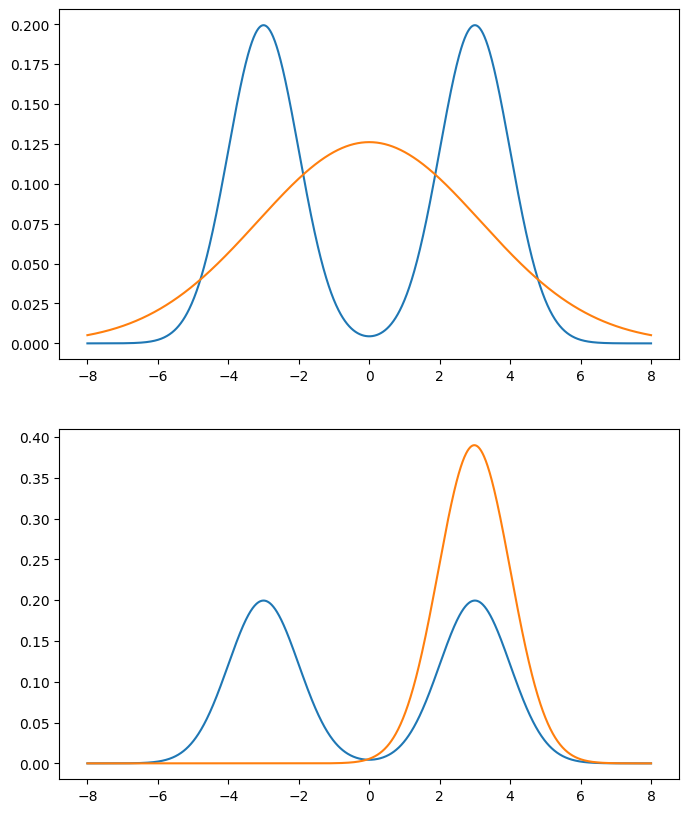

In [22]:
# --- imports: numpy, scipy.stats.norm, matplotlib ---
import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize
import matplotlib.pyplot as plt
%matplotlib inline

# --- helper functions ---

def p_density(x):
    # fixed bimodal target: weighted sum of two normal pdfs
    # return the mixture density evaluated at x
    # (you write this — it's trivial but it's yours)
    return 0.5*(norm.pdf(x, loc=-3, scale=1) + norm.pdf(x, loc=3, scale=1))

def q_density(x, mu, sigma):
    # single Gaussian pdf
    # (use norm.pdf — evaluating a density is not the lesson)
    return norm.pdf(x, loc=mu, scale=sigma)

def kl_forward(grid, mu, sigma):
    # D_KL(p || q) = ∫ p log(p/q)
    # YOU write the integrand. weight by p. guard the log (eps or mask).
    # integrate with trapz over grid. return scalar.
    p_dens = p_density(grid)
    # p_dens[p_dens < 1e-10] = 1e-10
    q_dens = q_density(grid, mu, sigma)
    # q_dens[q_dens < 1e-10] = 1e-10
    integrand = np.where(p_dens > 0, p_dens * np.log( p_dens / q_dens ), 0)
    return np.trapezoid(integrand, x=grid)

def kl_reverse(grid, mu, sigma):
    # D_KL(q || p) = ∫ q log(q/p)
    # YOU write this. note what changed vs forward: which density
    # multiplies the log, and which one you're integrating against.
    # this single difference is the entire week.
    p_dens = p_density(grid)
    # p_dens[p_dens < 1e-10] = 1e-10
    q_dens = q_density(grid, mu, sigma)
    # q_dens[q_dens < 1e-10] = 1e-10
    integrand = np.where(q_dens > 0, q_dens * np.log( q_dens / p_dens ), 0)
    return np.trapezoid(integrand, x=grid)

# --- the experiment ---
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(8, 10), sharex=False)

# grid = dense linspace covering both modes with margin
x = np.linspace(-8,8,1601)

# for direction in [kl_forward, kl_reverse]
x0 = [2,0.5]
p_plot = p_density(x)
for idx, direction in enumerate([kl_forward, kl_reverse]):
    obj = lambda params: direction(x, params[0], params[1])
    res = minimize(obj, x0)
    mu_opt, sigma_opt = res.x
    q_opt = q_density(x, mu_opt, sigma_opt)
    axes[idx].plot(x, p_plot)
    axes[idx].plot(x, q_opt)
#     search over (mu, sigma):          # grid search or scipy.minimize
#         evaluate direction(grid, mu, sigma)
#         track best params + full trajectory
#     plot p_density and the fitted q_density on the same axes
    # observe: does q straddle the valley, or snap to one mode?